# Visualizing `backward()` step by step

This notebook isolates Micrograd's reverse-mode automatic differentiation. It shows:

1. The forward computation graph.
2. The reverse topological order used by `backward()`.
3. Each local `_backward()` call and the gradients accumulated by that step.

The example deliberately reuses `a`, so you can see why gradients must use `+=` rather than assignment.

In [1]:
from graphviz import Digraph
from IPython.display import Markdown, display

from my_utils.micrograd import Value, trace

## Visualization helpers

Every graph includes a legend. Node labels show the scalar value, its current gradient, and how many local backward contributions have been accumulated.

In [2]:
def topological_order(root):
    visited = set()
    order = []

    def visit(node):
        if node in visited:
            return
        visited.add(node)
        for child in node._prev:
            visit(child)
        order.append(node)

    visit(root)
    return order


def node_name(node):
    return node.label or node._op or "constant"


def draw_backward_state(root, active=None, processed=frozenset()):
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR", "bgcolor": "white"})
    dot.attr("node", fontname="Helvetica")
    dot.attr("edge", fontname="Helvetica", color="#6b7280")
    nodes, edges = trace(root)

    for node in nodes:
        uid = str(id(node))
        if node is active:
            fill = "#fbbf24"  # active: amber
        elif node in processed:
            fill = "#86efac"  # processed: green
        elif not node._prev:
            fill = "#93c5fd"  # leaf/input: blue
        else:
            fill = "#f3f4f6"  # pending: gray

        label = (
            "{" + f"{node_name(node)} | data={node.data:.4f} | "
            f"grad={node.grad:.4f} | updates={node._gradient_updates}" + "}"
        )
        dot.node(uid, label=label, shape="record", style="filled", fillcolor=fill)

        if node._op:
            op_uid = uid + "_op"
            op_fill = "#fde68a" if node is active else "#e5e7eb"
            dot.node(op_uid, label=node._op, shape="circle", style="filled", fillcolor=op_fill)
            dot.edge(op_uid, uid)

    for child, parent in edges:
        attrs = {}
        if parent is active:
            attrs = {"color": "#dc2626", "penwidth": "3", "label": " gradient flows back "}
        dot.edge(str(id(child)), str(id(parent)) + "_op", **attrs)

    with dot.subgraph(name="cluster_legend") as legend:
        legend.attr(label="Legend", color="#9ca3af", fontsize="12")
        legend.attr("node", shape="box", style="filled", fontsize="10")
        legend.node("legend_active", "Active _backward()", fillcolor="#fbbf24")
        legend.node("legend_processed", "Processed", fillcolor="#86efac")
        legend.node("legend_input", "Leaf / input", fillcolor="#93c5fd")
        legend.node("legend_pending", "Pending", fillcolor="#f3f4f6")
        legend.node("legend_edge", "Red edge = current gradient path", fillcolor="white")

    return dot

## 1. Build the forward graph

We compute $L = (a \times b + a) \times b$. Both `a` and `b` are reused, so their final gradients contain multiple contributions.

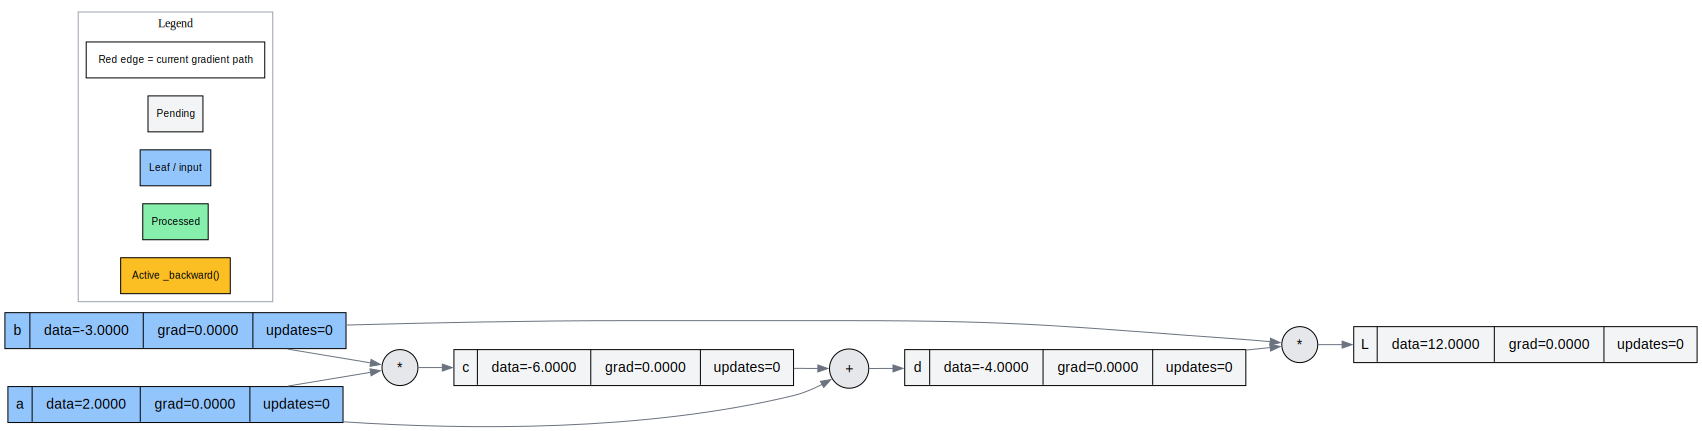

In [3]:
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = a * b; c.label = "c"
d = c + a; d.label = "d"
L = d * b; L.label = "L"

draw_backward_state(L)

## 2. Inspect the traversal order

`backward()` first performs a depth-first topological sort. Reversing that order guarantees that a node receives all downstream gradient contributions before its own `_backward()` function runs.

In [4]:
topo = topological_order(L)
reverse_order = list(reversed(topo))

print("Forward topological order:", " -> ".join(node_name(node) for node in topo))
print("Backward execution order: ", " -> ".join(node_name(node) for node in reverse_order))

Forward topological order: a -> b -> c -> d -> L
Backward execution order:  L -> d -> c -> b -> a


## 3. Run backward one local operation at a time

The amber node is executing its `_backward()` function. Red edges identify the operands receiving gradient contributions. Green nodes have already propagated their gradients.

### Seed gradient: $dL/dL = 1$

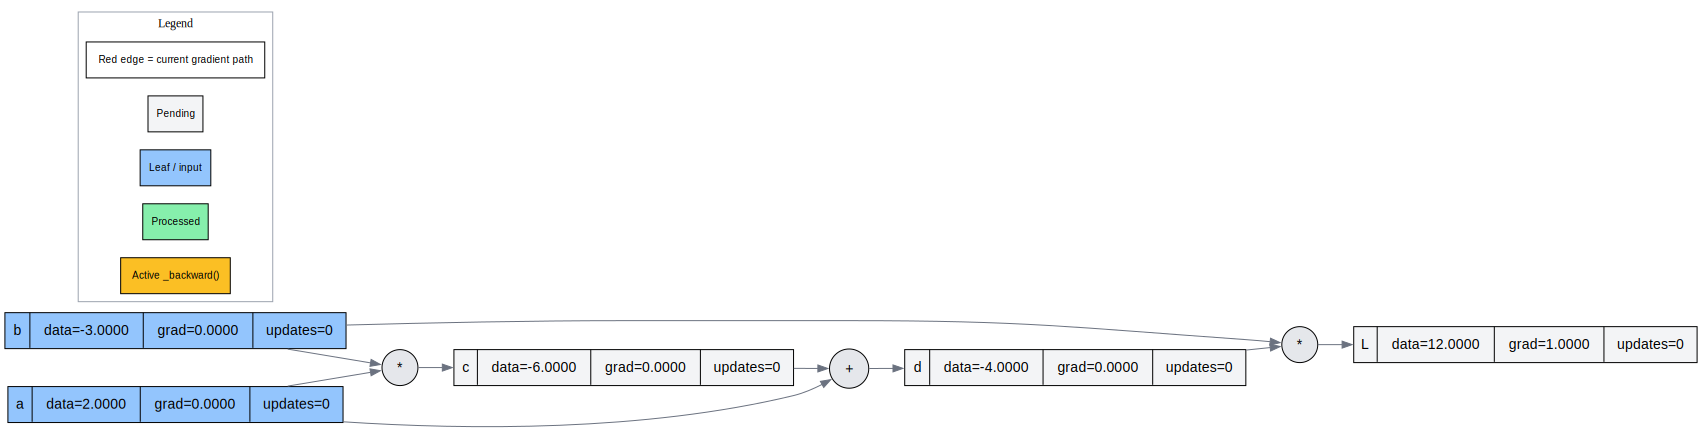

### Step 1: `L` calls `_backward()`
Gradient contribution(s): `d`: -3.0000, `b`: -4.0000

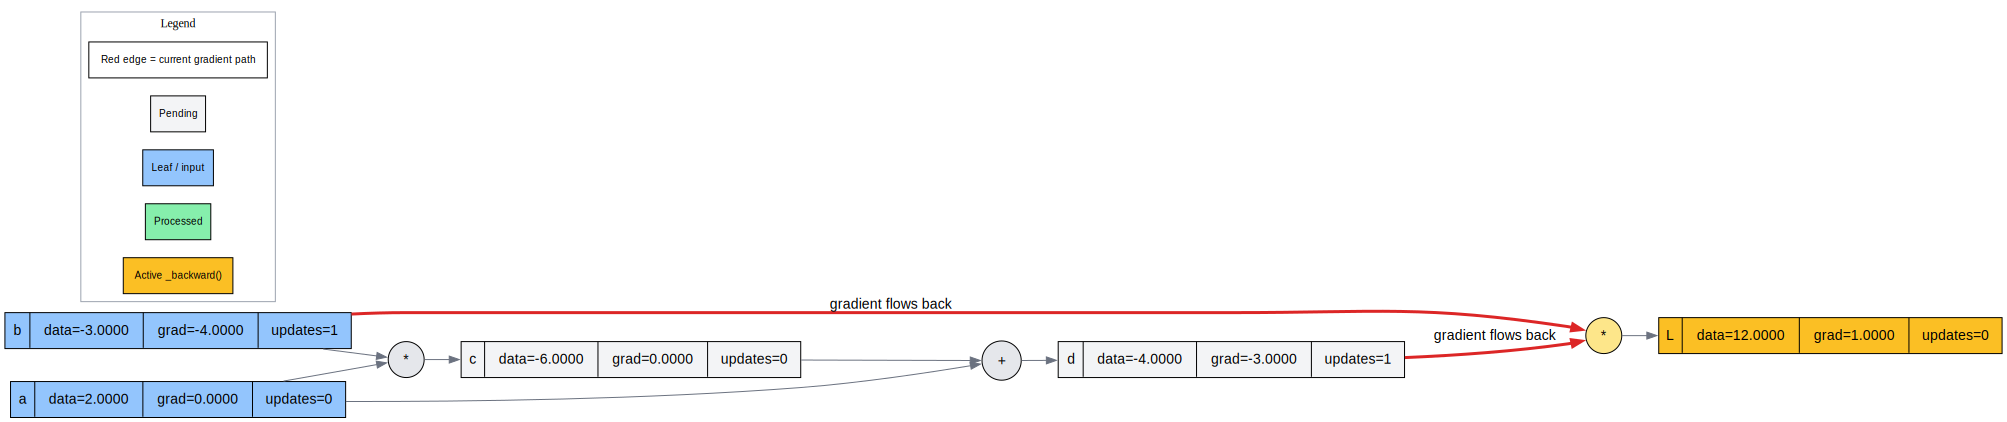

### Step 2: `d` calls `_backward()`
Gradient contribution(s): `a`: -3.0000, `c`: -3.0000

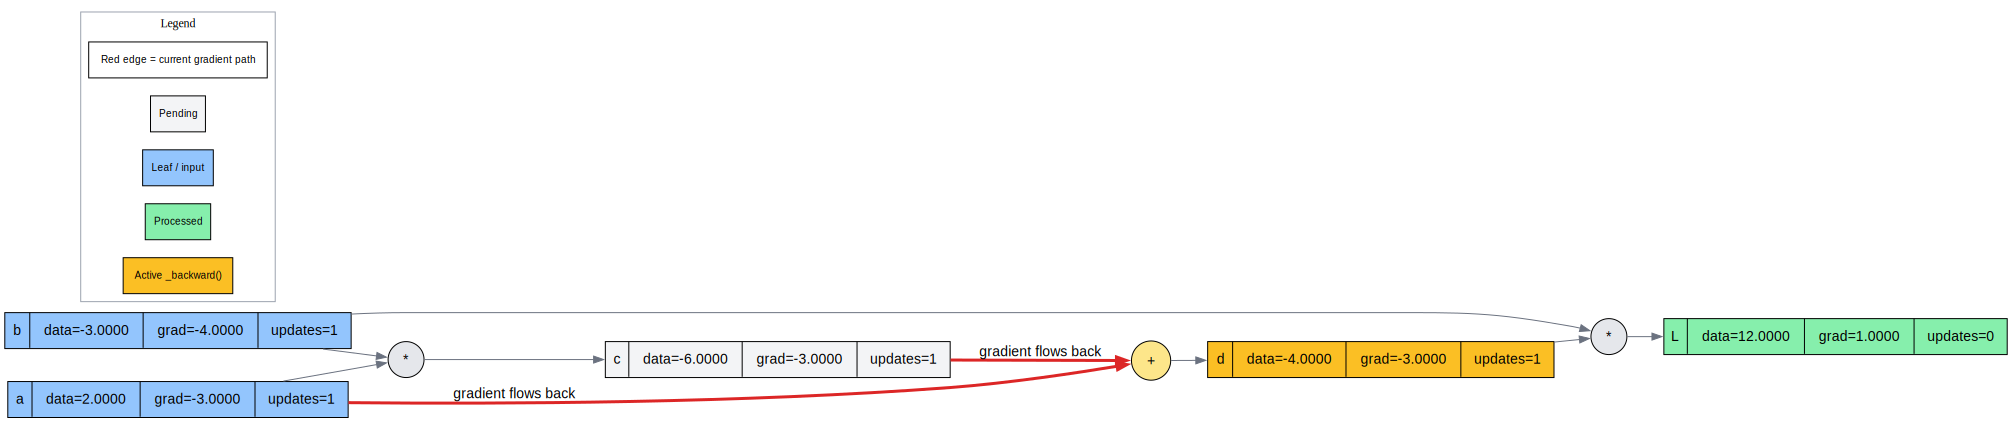

### Step 3: `c` calls `_backward()`
Gradient contribution(s): `a`: +9.0000, `b`: -6.0000

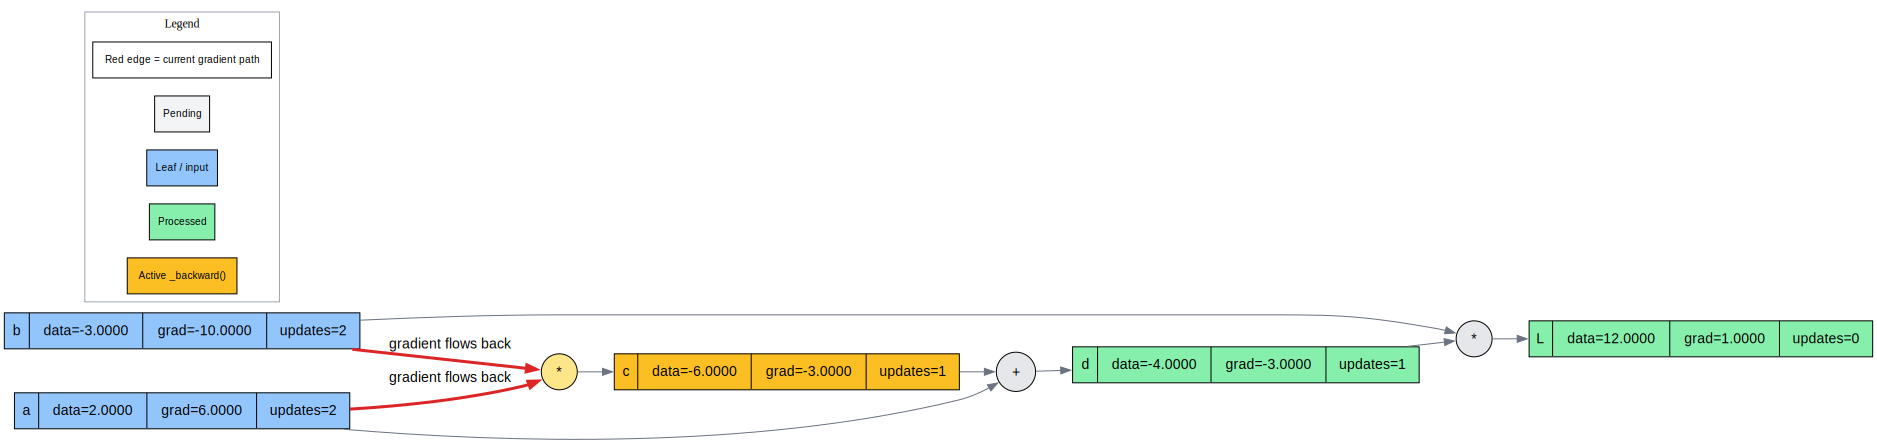

### Step 4: `b` calls `_backward()`
Gradient contribution(s): none (leaf node)

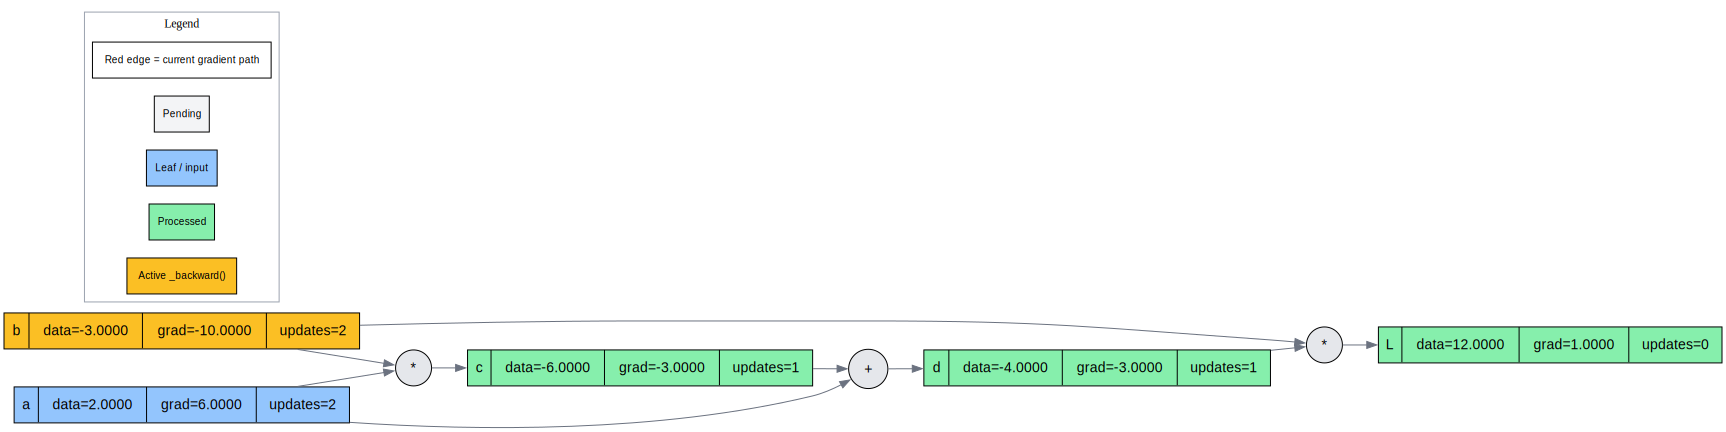

### Step 5: `a` calls `_backward()`
Gradient contribution(s): none (leaf node)

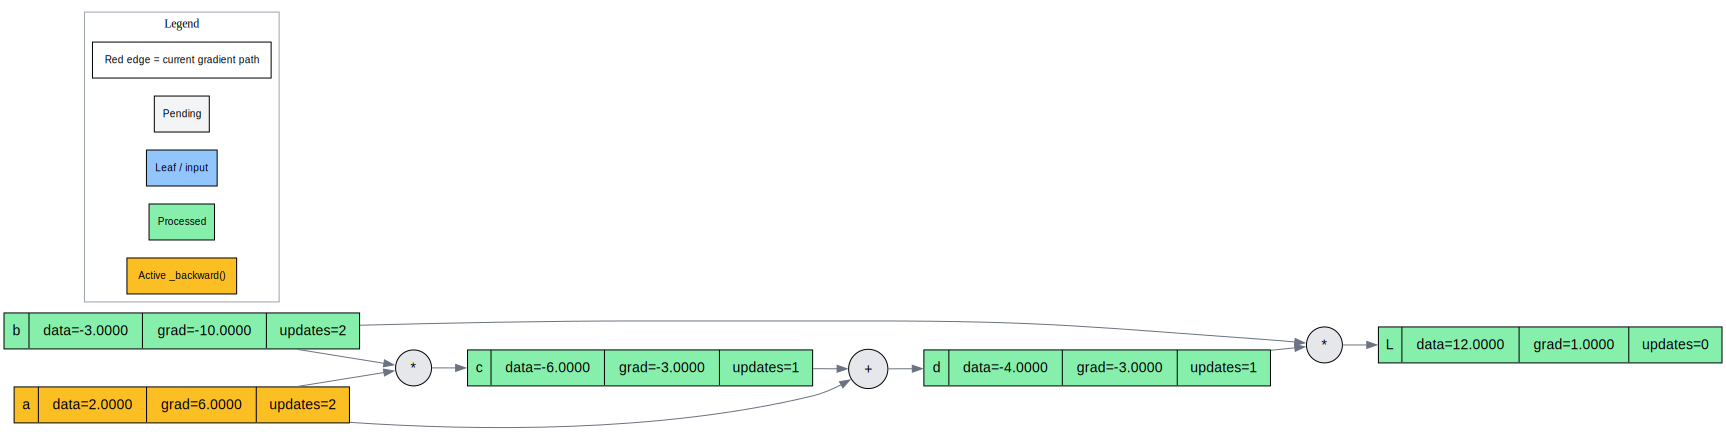

In [5]:
for node in topo:
    node.grad = 0.0
    node._gradient_updates = 0

L.grad = 1.0
processed = set()

display(Markdown("### Seed gradient: $dL/dL = 1$"))
display(draw_backward_state(L, processed=processed))

for step, node in enumerate(reverse_order, start=1):
    before = {child: child.grad for child in node._prev}
    node._backward()
    contributions = [
        f"`{node_name(child)}`: {child.grad - before[child]:+.4f}"
        for child in node._prev
    ]
    contribution_text = ", ".join(contributions) if contributions else "none (leaf node)"
    display(Markdown(
        f"### Step {step}: `{node_name(node)}` calls `_backward()`\n"
        f"Gradient contribution(s): {contribution_text}"
    ))
    display(draw_backward_state(L, active=node, processed=processed))
    processed.add(node)

## 4. Final gradients

For $L = (ab+a)b = ab^2 + ab$:

- $\frac{dL}{da} = b^2+b = 6$
- $\frac{dL}{db} = 2ab+a = -10$

The calculated gradients below should match those analytical derivatives.

dL/da = 6.0
dL/db = -10.0


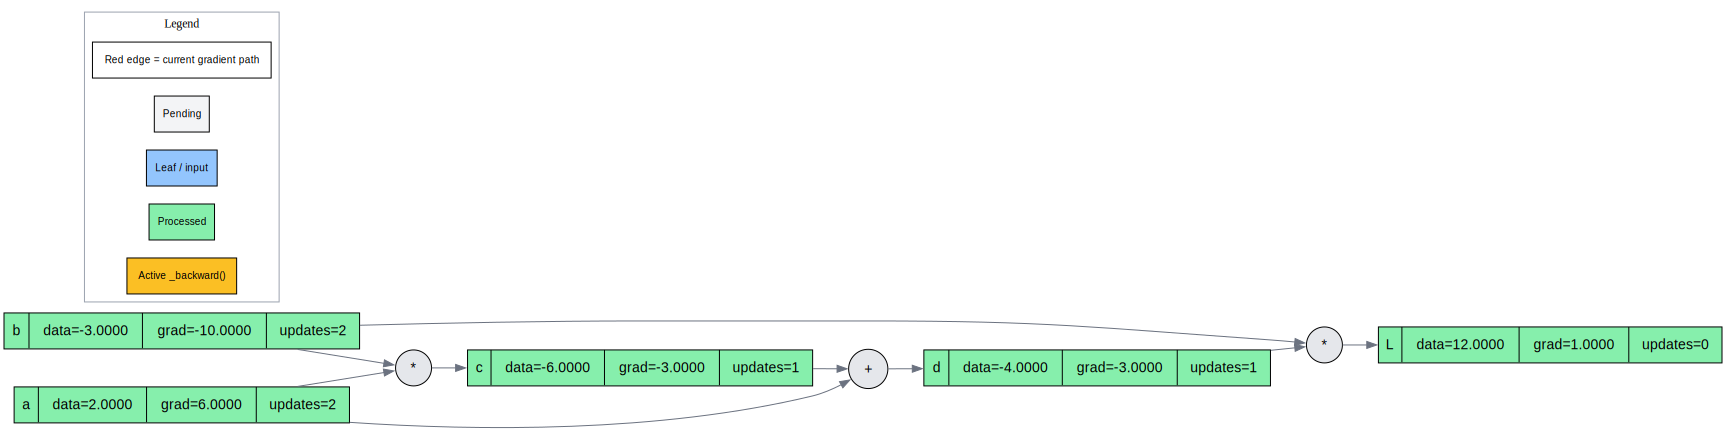

In [6]:
assert a.grad == 6.0
assert b.grad == -10.0

print(f"dL/da = {a.grad:.1f}")
print(f"dL/db = {b.grad:.1f}")
draw_backward_state(L, processed=set(topo))